# Healthcare Provider Fraud Detection

Medicare fraud usually happens at the provider level. A hospital or clinic bills for more than it should, again and again. The problem is that the data doesn't come one row per provider. It comes one row per claim, and there are more than 500K of them.

So in this notebook I turn the claims into a set of features for each provider, train a Random Forest to spot the fraudulent ones, and check how well it does using PR-AUC.

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, auc

## 1. Loading the data
There are four files. One says which providers are fraudulent, one has patient details, and two have the claims: inpatient (the patient was admitted to hospital) and outpatient (they weren't).

In [2]:
labels = pd.read_csv('/kaggle/input/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/Train-1542865627584.csv')
beneficiary = pd.read_csv('/kaggle/input/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/Train_Beneficiarydata-1542865627584.csv')
inpatient = pd.read_csv('/kaggle/input/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/Train_Inpatientdata-1542865627584.csv')
outpatient = pd.read_csv('/kaggle/input/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/Train_Outpatientdata-1542865627584.csv')

print('Providers        :', len(labels))
print('Patients         :', len(beneficiary))
print('Inpatient claims :', len(inpatient))
print('Outpatient claims:', len(outpatient))

Providers        : 5410
Patients         : 138556
Inpatient claims : 40474
Outpatient claims: 517737


## 2. Putting all the claims together
I stack the inpatient and outpatient claims into one table. Before that I add a column saying which type each claim is, so that information isn't lost.

In [3]:
# 1 = inpatient, 0 = outpatient
inpatient['Is_Inpatient'] = 1
outpatient['Is_Inpatient'] = 0

claims = pd.concat([inpatient, outpatient], ignore_index=True)
print('Total claims:', len(claims))

# missing amounts mean nothing was paid
claims['InscClaimAmtReimbursed'] = claims['InscClaimAmtReimbursed'].fillna(0)
claims['DeductibleAmtPaid'] = claims['DeductibleAmtPaid'].fillna(0)

Total claims: 558211


## 3. Feature engineering
The fraud label is given per provider, but everything else is per claim. So I need to summarise each provider's claims into one row of numbers the model can learn from.

First, a risk score for each patient. The patient file has 11 chronic condition columns (diabetes, heart failure and so on), coded 1 for yes and 2 for no. I change the 2s to 0s and add them up, which gives the number of chronic conditions each patient has.

In [4]:
# chronic condition columns
chronic_cols = [col for col in beneficiary.columns if 'ChronicCond' in col]

# 2 = no, change it to 0
beneficiary[chronic_cols] = beneficiary[chronic_cols].replace(2, 0)
beneficiary['Patient_Risk_Score'] = beneficiary[chronic_cols].sum(axis=1)

# add the risk score to each claim
claims = pd.merge(claims, beneficiary[['BeneID', 'Patient_Risk_Score']], on='BeneID', how='left')

In [5]:
# claim length in days (+1 so same-day claims count as 1)
claims['ClaimStartDt'] = pd.to_datetime(claims['ClaimStartDt'])
claims['ClaimEndDt'] = pd.to_datetime(claims['ClaimEndDt'])
claims['Claim_Duration'] = (claims['ClaimEndDt'] - claims['ClaimStartDt']).dt.days + 1

Now the main step. I group all claims by provider and work out a few numbers for each one:
- how many claims they filed and how many different patients they saw
- how much Medicare paid them in total, and how much patients paid as deductibles
- the average claim length and the share of claims that were inpatient
- how sick their patients are on average
- claims per patient, since billing the same patients over and over is a common fraud pattern

In [6]:
provider = claims.groupby('Provider').agg(
    Total_Claims=('ClaimID', 'count'),
    Unique_Patients=('BeneID', 'nunique'),
    Total_Reimbursed=('InscClaimAmtReimbursed', 'sum'),
    Total_Deductible=('DeductibleAmtPaid', 'sum'),
    Avg_Claim_Duration=('Claim_Duration', 'mean'),
    Inpatient_Ratio=('Is_Inpatient', 'mean'),
    Avg_Patient_Risk=('Patient_Risk_Score', 'mean'),
).reset_index()

provider['Claims_Per_Patient'] = provider['Total_Claims'] / provider['Unique_Patients']

provider.head()

,Provider,Total_Claims,Unique_Patients,Total_Reimbursed,Total_Deductible,Avg_Claim_Duration,Inpatient_Ratio,Avg_Patient_Risk,Claims_Per_Patient
0,PRV51001,25,24,104640,5340.0,2.440000,0.200000,5.560000,1.041667
1,PRV51003,132,117,605670,66286.0,4.674242,0.469697,4.545455,1.128205
2,PRV51004,149,138,52170,310.0,2.429530,0.000000,4.342282,1.079710
3,PRV51005,1165,495,280910,3700.0,2.088412,0.000000,4.335622,2.353535
4,PRV51007,72,58,33710,3264.0,1.958333,0.041667,4.166667,1.241379


In [7]:
# add the fraud label, Yes = 1, No = 0
provider = pd.merge(provider, labels, on='Provider')
provider['PotentialFraud'] = provider['PotentialFraud'].map({'Yes': 1, 'No': 0})

print('Providers:', len(provider))
print('Fraud rate:', round(provider['PotentialFraud'].mean() * 100, 1), '%')

Providers: 5410
Fraud rate: 9.4 %


## 4. Training the model
Only about 9% of providers are fraudulent. If I trained the model as it is, it would mostly learn to say "not fraud" because that's right 91% of the time.

To stop that I use `class_weight='balanced'`. This makes a mistake on a fraud case cost the model much more than a mistake on a normal one, so it has to pay attention to the rare class. I also use `stratify=y` in the split so both the training and test sets keep the same 9% fraud rate.

In [8]:
X = provider.drop(['Provider', 'PotentialFraud'], axis=1)
y = provider['PotentialFraud']

# 80/20 split, same fraud rate in both
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## 5. Checking the model with PR-AUC
Accuracy doesn't work here. A model that says "not fraud" for every single provider would still be about 91% accurate and catch nothing.

PR-AUC looks at precision (of the providers I flag, how many are really fraud) and recall (of all the fraud, how much I catch) across every possible cut-off, and gives one score between 0 and 1. A model that guesses randomly would score roughly the fraud rate, about 0.09.

In [9]:
# probability of fraud for each provider in the test set
probs = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

print('PR-AUC:', round(pr_auc, 3))
print('Random guessing would score about:', round(y_test.mean(), 3))

PR-AUC: 0.712
Random guessing would score about: 0.093


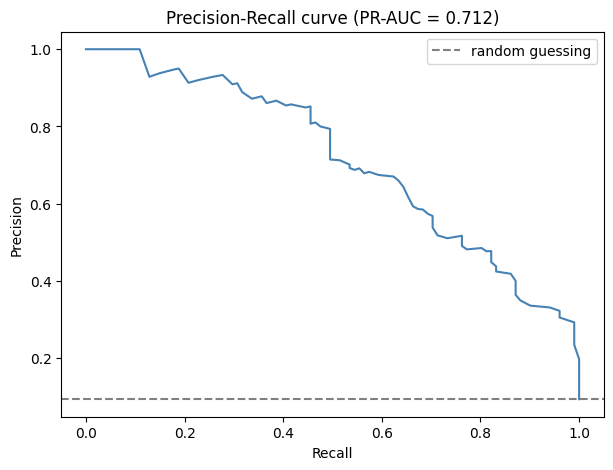

In [10]:
# precision-recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='steelblue')
plt.axhline(y_test.mean(), color='grey', linestyle='--', label='random guessing')
plt.title('Precision-Recall curve (PR-AUC = ' + str(round(pr_auc, 3)) + ')')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

## 6. Comparing with a Decision Tree
A single Decision Tree is easier to explain to someone non-technical, since you can literally draw its rules. So I trained one with the same settings to see how much the Random Forest actually adds. I kept the tree shallow (depth 5) so it stays readable.

In [11]:
# single tree, same class weighting
tree = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

tree_probs = tree.predict_proba(X_test)[:, 1]
tree_precision, tree_recall, _ = precision_recall_curve(y_test, tree_probs)
tree_pr_auc = auc(tree_recall, tree_precision)

print('Random Forest PR-AUC:', round(pr_auc, 3))
print('Decision Tree PR-AUC:', round(tree_pr_auc, 3))

Random Forest PR-AUC: 0.712
Decision Tree PR-AUC: 0.456


## 7. Which features matter most?
The Random Forest keeps track of how much each feature helped it split fraud from non-fraud. Higher means more useful.

              Feature  Importance
2    Total_Reimbursed       0.336
3    Total_Deductible       0.182
5     Inpatient_Ratio       0.102
0        Total_Claims       0.090
1     Unique_Patients       0.083
4  Avg_Claim_Duration       0.080
7  Claims_Per_Patient       0.064
6    Avg_Patient_Risk       0.062


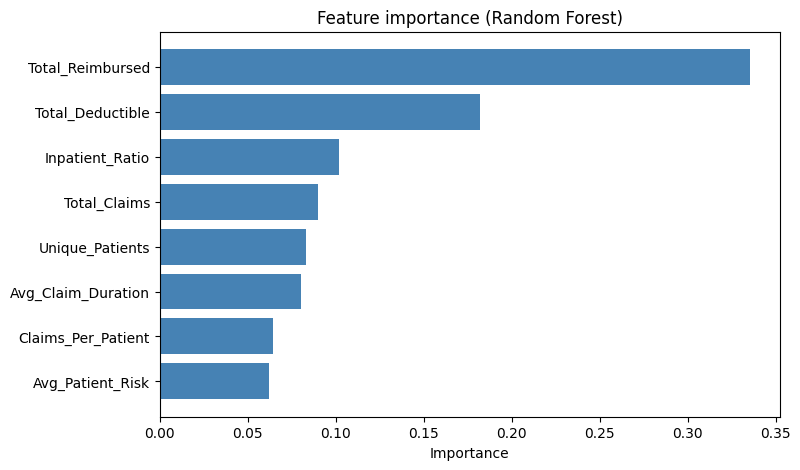

In [12]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.round(3))

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.title('Feature importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

## 8. Saving the data for Tableau
I export the provider-level table so I can build the dashboard in Tableau.

In [13]:
provider.to_csv('final_provider_fraud_data.csv', index=False)
print('Saved final_provider_fraud_data.csv')

Saved final_provider_fraud_data.csv
